<a href="https://colab.research.google.com/github/Sameer0Rai/Deep-Learning/blob/main/Lab-Assignments/Lab_5_Learning_by_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the Abalone dataset directly from UCI repository

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"

columns = [
    "Sex","Length","Diameter","Height",
    "WholeWeight","ShuckedWeight",
    "VisceraWeight","ShellWeight","Rings"
]

data = pd.read_csv(url, names=columns)

# TODO: print number of rows
print("Number of rows:", len(data))

# TODO: print column names
print("Column names:", data.columns.tolist())

# TODO: print first 5 rows
data.head()

Number of rows: 4177
Column names: ['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight', 'VisceraWeight', 'ShellWeight', 'Rings']


,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


#Part A1

In [3]:
# Checkpoint:
# what is input:
# The inputs are the physical measurements of the abalone
# such as length, diameter, height, and different weight measures.

# what is output:
# The output is the predicted age of the abalone.

# why output is numeric:
# Age is represented using the "Rings" value in the dataset.
# Since age is a continuous numerical quantity, predicting it
# becomes a regression problem rather than classification.

#Part A2

In [4]:
# According to the dataset documentation:
# Age ≈ Rings + 1.5

data["Age"] = data["Rings"] + 1.5

y = data["Age"].values.reshape(-1,1)

print("Target shape:", y.shape)

Target shape: (4177, 1)


#Part A3

In [5]:
# We select three numeric features that are likely related to age.

features = ["Length","Diameter","WholeWeight"]

X = data[features].values

print("Selected features:", features)
print("Input shape:", X.shape)

Selected features: ['Length', 'Diameter', 'WholeWeight']
Input shape: (4177, 3)


In [6]:
# Justification:

# Feature 1: Length
# Older abalones generally grow longer, so length should correlate with age.

# Feature 2: Diameter
# Diameter captures the shell width which increases as the organism grows.

# Feature 3: WholeWeight
# Heavier abalones are typically older because they accumulate mass over time.

# These three features together describe size and body mass,
# which are reasonable indicators of biological age.

#Part A4

In [8]:
# Training and testing split- 80,20

N = X.shape[0]
split = int(0.8 * N)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3341, 3)
Test shape: (836, 3)


#Part A5

In [9]:
# Normalization helps gradient descent converge faster.
# If one feature has a much larger scale than others,
# the optimization may become unstable or very slow.

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [10]:
# Checkpoint:
# why normalization is needed for learning:

# Gradient descent updates parameters using slopes.
# If features have very different scales,
# the loss surface becomes stretched and optimization zig-zags.
# Normalizing keeps features on similar scales,
# making learning more stable and faster.

#Part B

In [11]:
def forward(X, w, b):

    y_hat = X @ w + b

    print("X shape:", X.shape)
    print("w shape:", w.shape)
    print("b shape:", np.shape(b))
    print("y_hat shape:", y_hat.shape)

    return y_hat

In [12]:
# Checkpoint:
# parameters are:
# The parameters are the weights (w) and bias (b)

# number of parameters:
# We selected d = 3 features
# so there are 3 weights + 1 bias
# total parameters = 4

#Part C

In [13]:
def mse(y, y_hat):

    N = len(y)

    loss = (1/N) * np.sum((y - y_hat)**2)

    return loss

In [14]:
# Checkpoint:

# why square:
# Squaring ensures errors are always positive and prevents
# positive and negative errors from cancelling out.

# what mistakes are expensive:
# Large prediction errors become very expensive under MSE
# because the error is squared.

#Part D

In [15]:
# Checkpoint:

# what gradient means in words:
# A gradient tells us the direction in which the loss increases the most.
# It is essentially the slope of the loss function with respect to parameters.

# why subtracting gradient reduces loss:
# Since the gradient points toward increasing loss,
# subtracting it moves parameters in the direction that decreases loss.

In [16]:
def grad_w(X, y, y_hat):

    N = X.shape[0]

    dW = (2/N) * X.T @ (y_hat - y)

    return dW


def grad_b(y, y_hat):

    N = y.shape[0]

    db = (2/N) * np.sum(y_hat - y)

    return db

In [17]:
# Checkpoint:

# meaning of large gradient:
# A large gradient means the loss is changing very rapidly.
# The parameters are far from the optimal values.

# effect of too-large learning rate:
# If learning rate is too large,
# updates may overshoot the minimum and training can diverge.

#Part E

In [18]:
d = X_train.shape[1]

w = np.random.randn(d,1) * 0.01
b = 0

print("Initial w:", w)
print("Initial b:", b)

Initial w: [[0.01357361]
 [0.01584396]
 [0.00848191]]
Initial b: 0


In [19]:
lr = 0.01
epochs = 500
k = 50

loss_history = []

for epoch in range(epochs):

    # 1 Forward pass
    y_hat = X_train @ w + b

    # 2 Loss
    loss = mse(y_train, y_hat)

    # 3 Gradients
    dW = grad_w(X_train, y_train, y_hat)
    db = grad_b(y_train, y_hat)

    # 4 Update
    w = w - lr * dW
    b = b - lr * db

    loss_history.append(loss)

    if epoch % k == 0:
        print("Epoch:", epoch, "Loss:", loss)

Epoch: 0 Loss: 144.15886915436423
Epoch: 50 Loss: 25.14729047354565
Epoch: 100 Loss: 9.813646810530772
Epoch: 150 Loss: 7.776942742528727
Epoch: 200 Loss: 7.502739022215413
Epoch: 250 Loss: 7.46248491591459
Epoch: 300 Loss: 7.453444147920481
Epoch: 350 Loss: 7.448710110298644
Epoch: 400 Loss: 7.444697756784708
Epoch: 450 Loss: 7.440917519753062


In [20]:
# Initial expectation:
# Since this is a simple linear model with only a few parameters,
# we expect the loss to decrease steadily over epochs.

# Revised expectation after training:
# The loss decreases gradually rather than instantly,
# which is expected because gradient descent updates parameters step by step.

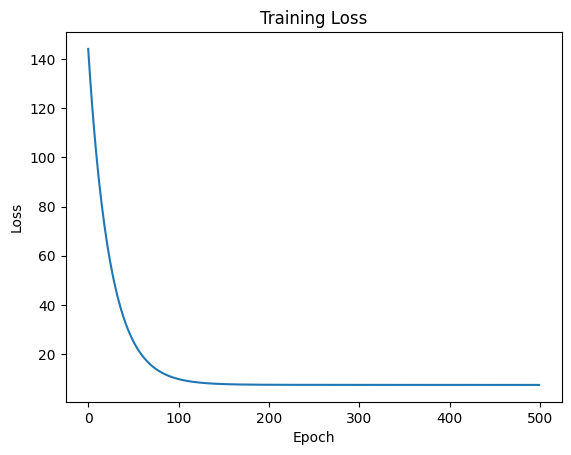

In [21]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

#Part F

In [22]:
y_pred = X_test @ w + b

test_mse = mse(y_test, y_pred)

mae = np.mean(np.abs(y_test - y_pred))

print("Test MSE:", test_mse)
print("Test MAE:", mae)

Test MSE: 5.364355429629788
Test MAE: 1.8103057553425161


In [23]:
print("Sample Predictions\n")

for i in range(5):

    true_age = y_test[i][0]
    pred_age = y_pred[i][0]
    error = abs(true_age - pred_age)

    print("True Age:", round(true_age,2),
          "Predicted:", round(pred_age,2),
          "Absolute Error:", round(error,2))

Sample Predictions

True Age: 13.5 Predicted: 11.02 Absolute Error: 2.48
True Age: 15.5 Predicted: 9.94 Absolute Error: 5.56
True Age: 14.5 Predicted: 10.44 Absolute Error: 4.06
True Age: 14.5 Predicted: 10.86 Absolute Error: 3.64
True Age: 13.5 Predicted: 10.88 Absolute Error: 2.62


In [24]:
# Checkpoint:

# systematic errors:
# The model sometimes underestimates the age of older abalones.
# This suggests that the linear model cannot fully capture
# complex relationships in the data.

# observed bias:
# Predictions tend to cluster near the average age.
# This is a common behavior of simple regression models,
# which may struggle with extreme values.